# Gradient Descent (One Variable)

Goal: learn `w` and `b` in `y_hat = w*x + b` using simple gradient descent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([1.1, 2.9, 5.2, 6.8, 9.1, 10.9], dtype=float)

print('X:', X)
print('y:', y)

X: [0. 1. 2. 3. 4. 5.]
y: [ 1.1  2.9  5.2  6.8  9.1 10.9]


## Update Rule (Single Variable)

For `y_hat = w*x + b`:
- `error = (w*x + b) - y`
- `dw = (1/m) * sum(error * x)`
- `db = (1/m) * sum(error)`
- update: `w = w - lr*dw`, `b = b - lr*db`

Same idea as multi-variable gradient descent, but with scalar `w` and 1D `x`.

In [2]:
def compute_mse(x, y, w, b):
    y_hat = w * x + b
    return np.mean((y_hat - y) ** 2)


def gradient_step(x, y, w, b, lr):
    """One gradient descent step for single-variable regression."""
    m = x.shape[0]
    error = (w * x + b) - y

    dw = (1 / m) * np.sum(error * x)
    db = (1 / m) * np.sum(error)

    w = w - lr * dw
    b = b - lr * db
    return w, b


def gradient_descent(x, y, lr=0.05, epochs=200):
    w, b = 0.0, 0.0
    history = []

    for _ in range(epochs):
        w, b = gradient_step(x, y, w, b, lr)
        history.append(compute_mse(x, y, w, b))

    return w, b, history


Final:
w=1.9838, b=1.0335


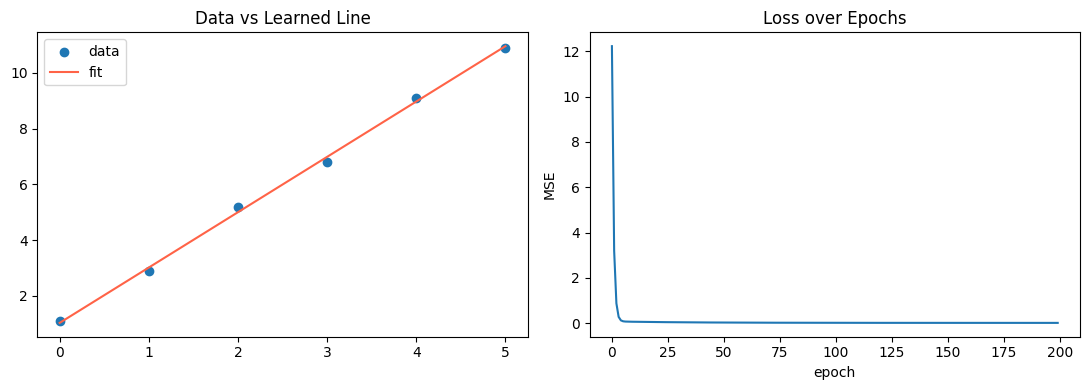

In [3]:
w, b, history = gradient_descent(X, y, lr=0.05, epochs=200)
print('\nFinal:')
print(f'w={w:.4f}, b={b:.4f}')

y_hat = w * X + b
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(X, y, label='data')
axes[0].plot(X, y_hat, color='tomato', label='fit')
axes[0].set_title('Data vs Learned Line')
axes[0].legend()

axes[1].plot(history)
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('MSE')
plt.tight_layout()
plt.show()

## Takeaway

- `w` controls slope, `b` shifts the line.
- Gradients tell direction; `alpha` controls step size.
- Repeated small updates reduce loss.